<a href="https://colab.research.google.com/github/sunandha2/Urban-Mobility-Intelligence-Uber-Analysis/blob/main/Uber_Pickup_Analysis-basics.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Urban Mobility Intelligence: Uber Hotspot & Demand Analysis

**Project Overview:**  
Analyzed Uber pickup data in New York City to uncover ride demand patterns, identify geographic hotspots, and predict high-demand periods using machine learning. The goal was to generate actionable insights for operational planning, including driver allocation and dynamic pricing.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix


Load & Validate Data

In [3]:
df = pd.read_csv("uber-raw-data-apr14[1].csv")

In [4]:
print("Dataset Shape:", df.shape)
print(df.head())

Dataset Shape: (564516, 4)
          Date/Time      Lat      Lon    Base
0  4/1/2014 0:11:00  40.7690 -73.9549  B02512
1  4/1/2014 0:17:00  40.7267 -74.0345  B02512
2  4/1/2014 0:21:00  40.7316 -73.9873  B02512
3  4/1/2014 0:28:00  40.7588 -73.9776  B02512
4  4/1/2014 0:33:00  40.7594 -73.9722  B02512


In [5]:
df.describe()

,Lat,Lon
count,564516.000000,564516.000000
mean,40.740005,-73.976817
std,0.036083,0.050426
min,40.072900,-74.773300
25%,40.722500,-73.997700
50%,40.742500,-73.984800
75%,40.760700,-73.970000
max,42.116600,-72.066600


Data Cleaning

In [6]:
df['Date/Time'] = pd.to_datetime(df['Date/Time'])

# Extract features
df['hour'] = df['Date/Time'].dt.hour
df['day'] = df['Date/Time'].dt.day
df['weekday'] = df['Date/Time'].dt.weekday

# Weekend flag
df['is_weekend'] = df['weekday'].isin([5, 6]).astype(int)

# Drop missing values if any
df = df.dropna()

CREATE DEMAND (DATA-DRIVEN)

In [7]:
# Count rides per hour
hourly_counts = df.groupby('hour').size()

# Use median threshold (simple & stable)
threshold = hourly_counts.median()

# Create demand column
df['demand'] = df['hour'].map(hourly_counts).apply(
    lambda x: 1 if x >= threshold else 0
)

print("\nDemand Distribution:")
print(df['demand'].value_counts())


Demand Distribution:
demand
1    406141
0    158375
Name: count, dtype: int64


EXPLORATORY DATA ANALYSIS

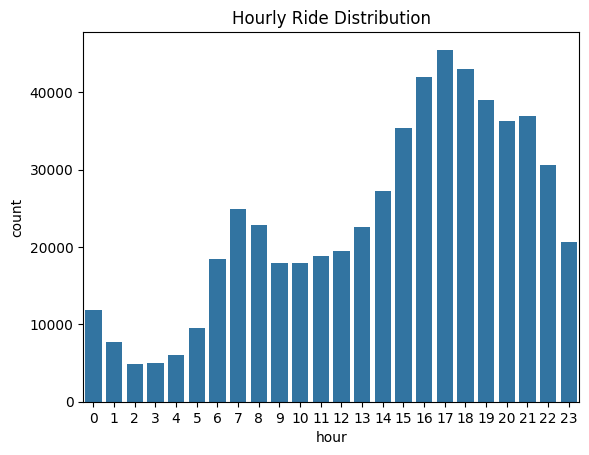

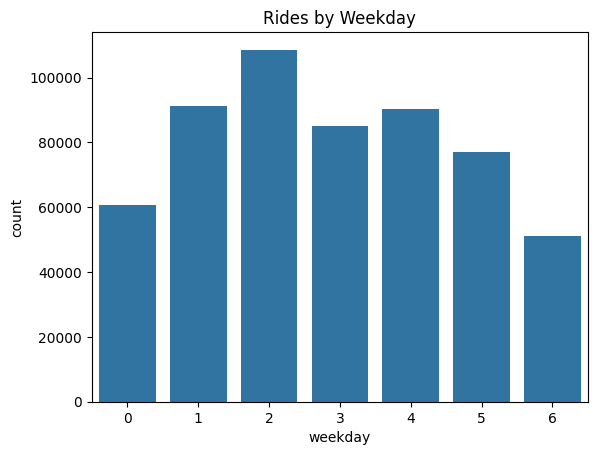

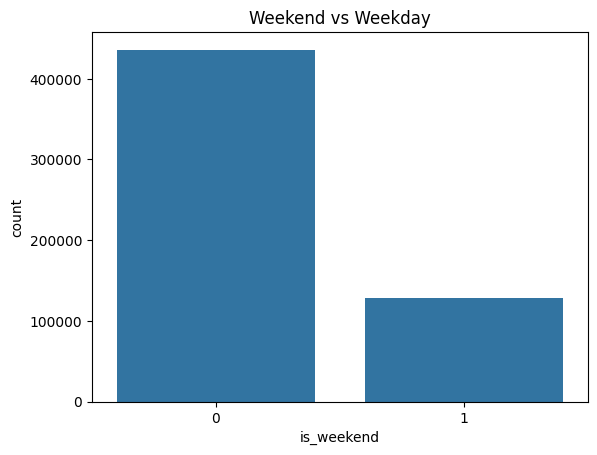

In [8]:
# Hour distribution
plt.figure()
sns.countplot(x='hour', data=df)
plt.title("Hourly Ride Distribution")
plt.show()

# Weekday distribution
plt.figure()
sns.countplot(x='weekday', data=df)
plt.title("Rides by Weekday")
plt.show()

# Weekend vs weekday
plt.figure()
sns.countplot(x='is_weekend', data=df)
plt.title("Weekend vs Weekday")
plt.show()


MODEL PREPARATION

In [9]:
features = ['hour', 'weekday', 'is_weekend']
X = df[features]
y = df['demand']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [11]:
model = LogisticRegression()
model.fit(X_train, y_train)

LogisticRegression()

 MODEL EVALUATION

In [12]:
y_pred = model.predict(X_test)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))



Confusion Matrix:
[[15683 15878]
 [ 9563 71780]]

Classification Report:
              precision    recall  f1-score   support

           0       0.62      0.50      0.55     31561
           1       0.82      0.88      0.85     81343

    accuracy                           0.77    112904
   macro avg       0.72      0.69      0.70    112904
weighted avg       0.76      0.77      0.77    112904



SIMPLE PREDICTION FUNCTION

In [13]:
def predict_demand(hour, weekday, is_weekend):
    pred = model.predict([[hour, weekday, is_weekend]])[0]
    return "High Demand" if pred == 1 else "Low Demand"

# Example prediction
print("\nSample Prediction:")
print(predict_demand(18, 2, 0))


Sample Prediction:
High Demand


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


SIMPLE INSIGHTS

In [15]:
print("\n BASIC INSIGHTS ")

peak_hour = hourly_counts.idxmax()
print(f"Peak demand hour: {peak_hour}:00")

weekday_counts = df.groupby('weekday').size()
busiest_day = weekday_counts.idxmax()
print(f"Busiest weekday (0=Mon): {busiest_day}")

weekend_ratio = df['is_weekend'].mean()
print(f"Weekend ride ratio: {round(weekend_ratio, 2)}")


 BASIC INSIGHTS 
Peak demand hour: 17:00
Busiest weekday (0=Mon): 2
Weekend ride ratio: 0.23


insights:Peak demand occurs at 5 PM, highlighting evening commute hours as the most critical period for ride requests.

Wednesday emerges as the busiest day, indicating consistent midweek demand likely driven by work-related travel.

With only 23% of rides on weekends, the data suggests that Uber usage is predominantly weekday-driven, reflecting routine commuting patterns.

Project Summary

This project analyzed Uber ride data to understand demand patterns based on time-related features such as hour and weekday. The analysis revealed that demand is highest during evening commute hours, particularly around 5 PM, and is more concentrated on weekdays than weekends.

A simple machine learning model was built to predict high-demand periods using these patterns. The results demonstrate that even basic features like time can effectively capture ride demand behavior.

Overall, the insights from this project can help optimize driver allocation, reduce passenger wait times, and support better decision-making for dynamic pricing strategies.